In [155]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from category_encoders import BinaryEncoder
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Optional tools
# from user_agents import parse
# from ip2geotools.databases.noncommercial import DbIpCity as ip2geo
# from geopy.geocoders import Nominatim
# from geopy.distance import great_circle

sns.set(style='whitegrid')

#### connect with sql server


In [156]:
import pyodbc 
conn = pyodbc.connect(
    'Driver={ODBC Driver 17 for SQL Server};'
    'Server=LENOVO-LEGION-5;'
    'Database=AdventureWorksDW2019;'
    'Trusted_Connection=yes;'
)
                    

In [157]:
#select the important columns for analysis
query=("""
SELECT
    fs.SalesOrderNumber,
    fs.SalesOrderLineNumber,

    fs.OrderQuantity,
    fs.SalesAmount,
    fs.TaxAmt,
    fs.Freight,
    fs.DiscountAmount,

    c.FirstName,
    c.LastName,
    c.BirthDate,
    c.Gender,
    c.MaritalStatus,
    c.YearlyIncome,
    c.TotalChildren,
    c.DateFirstPurchase,


    p.EnglishProductName,
    p.Color,
    p.Class,
    p.ProductLine,


    d.FullDateAlternateKey AS OrderDate,
    d.CalendarYear,
    d.EnglishMonthName,

    g.City,
    g.EnglishCountryRegionName,
    
    pr.englishPromotionName,
    pr.DiscountPct,

    t.SalesTerritoryGroup

FROM FactInternetSales fs
JOIN DimCustomer c ON fs.CustomerKey = c.CustomerKey
JOIN DimProduct p ON fs.ProductKey = p.ProductKey
LEFT JOIN DimDate d ON fs.OrderDateKey = d.DateKey
LEFT JOIN DimGeography g ON c.GeographyKey = g.GeographyKey
LEFT JOIN DimPromotion pr ON fs.PromotionKey = pr.PromotionKey
LEFT JOIN DimSalesTerritory t ON fs.SalesTerritoryKey = t.SalesTerritoryKey
      """
)
df=pd.read_sql(query,conn)
df.to_csv('data.csv',index=False)

C:\Users\MichaelM\AppData\Local\Temp\ipykernel_35756\1418599526.py:50: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



In [158]:
df

,SalesOrderNumber,SalesOrderLineNumber,OrderQuantity,SalesAmount,TaxAmt,Freight,DiscountAmount,FirstName,LastName,BirthDate,...,Class,ProductLine,OrderDate,CalendarYear,EnglishMonthName,City,EnglishCountryRegionName,englishPromotionName,DiscountPct,SalesTerritoryGroup
0,SO43697,1,1,3578.2700,286.2616,89.4568,0.0,Cole,Watson,1952-02-19,...,H,R,2010-12-29,2010,December,Metchosin,Canada,No Discount,0.0,North America
1,SO43698,1,1,3399.9900,271.9992,84.9998,0.0,Rachael,Martinez,1970-06-17,...,H,M,2010-12-29,2010,December,Pantin,France,No Discount,0.0,Europe
2,SO43699,1,1,3399.9900,271.9992,84.9998,0.0,Sydney,Wright,1952-06-01,...,H,M,2010-12-29,2010,December,Lebanon,United States,No Discount,0.0,North America
3,SO43700,1,1,699.0982,55.9279,17.4775,0.0,Ruben,Prasad,1943-11-10,...,L,R,2010-12-29,2010,December,Beverly Hills,United States,No Discount,0.0,North America
4,SO43701,1,1,3399.9900,271.9992,84.9998,0.0,Christy,Zhu,1973-08-14,...,H,M,2010-12-29,2010,December,North Ryde,Australia,No Discount,0.0,Pacific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO75122,1,1,21.9800,1.7584,0.5495,0.0,Caleb,Lal,1976-12-10,...,None,M,2014-01-28,2014,January,Sooke,Canada,No Discount,0.0,North America
60394,SO75122,2,1,8.9900,0.7192,0.2248,0.0,Caleb,Lal,1976-12-10,...,None,S,2014-01-28,2014,January,Sooke,Canada,No Discount,0.0,North America
60395,SO75123,1,1,21.9800,1.7584,0.5495,0.0,Devin,Phillips,1983-08-11,...,None,M,2014-01-28,2014,January,Sooke,Canada,No Discount,0.0,North America
60396,SO75123,2,1,159.0000,12.7200,3.9750,0.0,Devin,Phillips,1983-08-11,...,None,M,2014-01-28,2014,January,Sooke,Canada,No Discount,0.0,North America


#### understand data


In [159]:
df.info()

# update dates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SalesOrderNumber          60398 non-null  object 
 1   SalesOrderLineNumber      60398 non-null  int64  
 2   OrderQuantity             60398 non-null  int64  
 3   SalesAmount               60398 non-null  float64
 4   TaxAmt                    60398 non-null  float64
 5   Freight                   60398 non-null  float64
 6   DiscountAmount            60398 non-null  float64
 7   FirstName                 60398 non-null  object 
 8   LastName                  60398 non-null  object 
 9   BirthDate                 60398 non-null  object 
 10  Gender                    60398 non-null  object 
 11  MaritalStatus             60398 non-null  object 
 12  YearlyIncome              60398 non-null  float64
 13  TotalChildren             60398 non-null  int64  
 14  DateFi

In [160]:
df['BirthDate']=pd.to_datetime(df['BirthDate'],errors='coerce')
df['OrderDate']=pd.to_datetime(df['OrderDate'],errors='coerce')
df['DateFirstPurchase']=pd.to_datetime(df['DateFirstPurchase'],errors='coerce')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   SalesOrderNumber          60398 non-null  object        
 1   SalesOrderLineNumber      60398 non-null  int64         
 2   OrderQuantity             60398 non-null  int64         
 3   SalesAmount               60398 non-null  float64       
 4   TaxAmt                    60398 non-null  float64       
 5   Freight                   60398 non-null  float64       
 6   DiscountAmount            60398 non-null  float64       
 7   FirstName                 60398 non-null  object        
 8   LastName                  60398 non-null  object        
 9   BirthDate                 60398 non-null  datetime64[ns]
 10  Gender                    60398 non-null  object        
 11  MaritalStatus             60398 non-null  object        
 12  YearlyIncome      

In [161]:
df.isna().sum()
#color have nans

SalesOrderNumber                0
SalesOrderLineNumber            0
OrderQuantity                   0
SalesAmount                     0
TaxAmt                          0
Freight                         0
DiscountAmount                  0
FirstName                       0
LastName                        0
BirthDate                       0
Gender                          0
MaritalStatus                   0
YearlyIncome                    0
TotalChildren                   0
DateFirstPurchase               0
EnglishProductName              0
Color                           0
Class                       38946
ProductLine                     0
OrderDate                       0
CalendarYear                    0
EnglishMonthName                0
City                            0
EnglishCountryRegionName        0
englishPromotionName            0
DiscountPct                     0
SalesTerritoryGroup             0
dtype: int64

In [162]:
df['Class']=df['Class'].fillna('Unknown')


In [163]:
#describe numric col
df.describe()

,SalesOrderLineNumber,OrderQuantity,SalesAmount,TaxAmt,Freight,DiscountAmount,BirthDate,YearlyIncome,TotalChildren,DateFirstPurchase,OrderDate,CalendarYear,DiscountPct
count,60398.000000,60398.0,60398.000000,60398.000000,60398.000000,60398.0,60398,60398.000000,60398.00000,60398,60398,60398.000000,60398.000000
mean,1.886321,1.0,486.086911,38.886954,12.152217,0.0,1969-05-27 03:52:51.800390740,59715.056790,1.85074,2012-12-31 09:02:38.429086976,2013-06-09 12:21:38.903937536,2012.902298,0.000794
min,1.000000,1.0,2.290000,0.183200,0.057300,0.0,1916-02-10 00:00:00,10000.000000,0.00000,2010-12-29 00:00:00,2010-12-29 00:00:00,2010.000000,0.000000
25%,1.000000,1.0,7.950000,0.636000,0.198800,0.0,1961-12-13 06:00:00,30000.000000,0.00000,2012-07-04 00:00:00,2013-04-03 00:00:00,2013.000000,0.000000
50%,2.000000,1.0,29.990000,2.399200,0.749800,0.0,1971-08-15 00:00:00,60000.000000,2.00000,2013-03-18 00:00:00,2013-07-14 00:00:00,2013.000000,0.000000
75%,2.000000,1.0,539.990000,43.199200,13.499800,0.0,1978-07-13 18:00:00,80000.000000,3.00000,2013-08-05 00:00:00,2013-10-18 00:00:00,2013.000000,0.000000
max,8.000000,1.0,3578.270000,286.261600,89.456800,0.0,1986-06-25 00:00:00,170000.000000,5.00000,2014-01-28 00:00:00,2014-01-28 00:00:00,2014.000000,0.200000
std,1.016328,0.0,928.489892,74.279193,23.212248,0.0,NaN,33065.426837,1.62107,NaN,NaN,0.477666,0.005427


In [164]:
#most cheap..
df[df['SalesAmount']==2.29] 


,SalesOrderNumber,SalesOrderLineNumber,OrderQuantity,SalesAmount,TaxAmt,Freight,DiscountAmount,FirstName,LastName,BirthDate,...,Class,ProductLine,OrderDate,CalendarYear,EnglishMonthName,City,EnglishCountryRegionName,englishPromotionName,DiscountPct,SalesTerritoryGroup
5551,SO51217,4,1,2.29,0.1832,0.0573,0.0,Alvin,Hu,1980-08-01,...,Unknown,S,2012-12-30,2012,December,Seaford,Australia,No Discount,0.0,Pacific
5590,SO51231,2,1,2.29,0.1832,0.0573,0.0,Jacqueline,Powell,1938-07-06,...,Unknown,S,2012-12-31,2012,December,Newport Beach,United States,No Discount,0.0,North America
5609,SO51241,3,1,2.29,0.1832,0.0573,0.0,Alexa,Bell,1973-11-24,...,Unknown,S,2012-12-31,2012,December,Santa Cruz,United States,No Discount,0.0,North America
5619,SO51244,4,1,2.29,0.1832,0.0573,0.0,Virginia,Fernandez,1974-05-03,...,Unknown,S,2012-12-31,2012,December,Berlin,Germany,No Discount,0.0,Europe
5641,SO51252,3,1,2.29,0.1832,0.0573,0.0,Kaylee,Gray,1973-01-02,...,Unknown,S,2013-01-01,2013,January,Burien,United States,No Discount,0.0,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60273,SO75073,2,1,2.29,0.1832,0.0573,0.0,Jonathan,Brown,1966-01-31,...,Unknown,S,2014-01-27,2014,January,Langford,Canada,No Discount,0.0,North America
60335,SO75098,3,1,2.29,0.1832,0.0573,0.0,Bianca,Hu,1967-01-08,...,Unknown,S,2014-01-28,2014,January,Ballard,United States,No Discount,0.0,North America
60355,SO75106,2,1,2.29,0.1832,0.0573,0.0,Jacqueline,Murphy,1966-09-17,...,Unknown,S,2014-01-28,2014,January,Oakland,United States,No Discount,0.0,North America
60381,SO75118,2,1,2.29,0.1832,0.0573,0.0,Frank,Ramos,1979-08-07,...,Unknown,S,2014-01-28,2014,January,Poing,Germany,No Discount,0.0,Europe


In [165]:
#most exp
df[df['SalesAmount']==3578.27]


,SalesOrderNumber,SalesOrderLineNumber,OrderQuantity,SalesAmount,TaxAmt,Freight,DiscountAmount,FirstName,LastName,BirthDate,...,Class,ProductLine,OrderDate,CalendarYear,EnglishMonthName,City,EnglishCountryRegionName,englishPromotionName,DiscountPct,SalesTerritoryGroup
0,SO43697,1,1,3578.27,286.2616,89.4568,0.0,Cole,Watson,1952-02-19,...,H,R,2010-12-29,2010,December,Metchosin,Canada,No Discount,0.0,North America
5,SO43702,1,1,3578.27,286.2616,89.4568,0.0,Colin,Anand,1972-08-14,...,H,R,2010-12-30,2010,December,Coronado,United States,No Discount,0.0,North America
6,SO43703,1,1,3578.27,286.2616,89.4568,0.0,Albert,Alvarez,1983-07-24,...,H,R,2010-12-30,2010,December,Perth,Australia,No Discount,0.0,Pacific
9,SO43706,1,1,3578.27,286.2616,89.4568,0.0,Edward,Brown,1975-01-23,...,H,R,2010-12-31,2010,December,Santa Monica,United States,No Discount,0.0,North America
10,SO43707,1,1,3578.27,286.2616,89.4568,0.0,Emma,Brown,1971-06-10,...,H,R,2010-12-31,2010,December,Lemon Grove,United States,No Discount,0.0,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196,SO46594,1,1,3578.27,286.2616,89.4568,0.0,Rachel,Powell,1983-01-10,...,H,R,2011-12-27,2011,December,Brisbane,Australia,No Discount,0.0,Pacific
2197,SO46595,1,1,3578.27,286.2616,89.4568,0.0,Julian,Henderson,1959-12-15,...,H,R,2011-12-27,2011,December,Watford,United Kingdom,No Discount,0.0,Europe
2200,SO46598,1,1,3578.27,286.2616,89.4568,0.0,Evelyn,Chandra,1986-05-05,...,H,R,2011-12-28,2011,December,München,Germany,No Discount,0.0,Europe
2201,SO46599,1,1,3578.27,286.2616,89.4568,0.0,Sierra,Parker,1944-10-09,...,H,R,2011-12-28,2011,December,Long Beach,United States,No Discount,0.0,North America


In [166]:
#describe cat col 
cat_col= df.select_dtypes(include='O').columns
for col in cat_col:
    print(f"number of uniques of \'{col}\': {df[col].nunique()}")
    print(f"uniques of \'{col}\':\n{df[col].unique()}")
    print()
    print("*" * 50)
    print()

number of uniques of 'SalesOrderNumber': 27659
uniques of 'SalesOrderNumber':
['SO43697' 'SO43698' 'SO43699' ... 'SO75121' 'SO75122' 'SO75123']

**************************************************

number of uniques of 'FirstName': 670
uniques of 'FirstName':
['Cole' 'Rachael' 'Sydney' 'Ruben' 'Christy' 'Colin' 'Albert' 'Julio'
 'Curtis' 'Edward' 'Emma' 'Brad' 'Martha' 'Katrina' 'Courtney' 'Abigail'
 'Latasha' 'Warren' 'Jonathon' 'Alexandra' 'Kevin' 'Lucas' 'Melanie'
 'Louis' 'Bonnie' 'Misty' 'Anne' 'Kelvin' 'Logan' 'Alyssa' 'Mayra'
 'Garrett' 'Rosa' 'Alejandro' 'Patrick' 'Richard' 'Casey' 'Lindsey'
 'Melody' 'Phillip' 'Cory' 'Jeremiah' 'Tamara' 'Marco' 'Haley' 'Manuel'
 'Christian' 'Alexandria' 'Paige' 'Stacey' 'Darrell' 'Luke' 'Tabitha'
 'Morgan' 'Kayla' 'Cedric' 'Shannon' 'Jackson' 'Jon' 'Tiffany' 'Brenda'
 'Ebony' 'Jacquelyn' 'Krystal' 'Eugene' 'Evan' 'Gabrielle' 'Ashley'
 'Damien' 'Arthur' 'Roy' 'Jessie' 'James' 'Troy' 'Clarence' 'Monique'
 'Melvin' 'Cameron' 'Jessica' 'Ivan' 'Clin

In [167]:
for col in cat_col:
    print(f"count of each unique of \'{col}\':\n{df[col].value_counts()}")
    print()
    print("*" * 50)
    print()

count of each unique of 'SalesOrderNumber':
SalesOrderNumber
SO70714    8
SO58845    8
SO72656    8
SO51555    7
SO60233    7
          ..
SO43711    1
SO43710    1
SO43709    1
SO43708    1
SO43707    1
Name: count, Length: 27659, dtype: int64

**************************************************

count of each unique of 'FirstName':
FirstName
Eduardo      338
Dalton       325
Jennifer     316
Alexandra    314
Katherine    307
            ... 
Rolando        1
Norimichi      1
Lanna          1
Lloyd          1
Muniraju       1
Name: count, Length: 670, dtype: int64

**************************************************

count of each unique of 'LastName':
LastName
Diaz           674
Hernandez      669
Garcia         603
Perez          574
Sanchez        564
              ... 
Selikoff         1
Sacksteder       1
Schare           1
Pulipalyam       1
Mirchandani      1
Name: count, Length: 375, dtype: int64

**************************************************

count of each unique of 'Gende

In [168]:
df.columns

Index(['SalesOrderNumber', 'SalesOrderLineNumber', 'OrderQuantity',
       'SalesAmount', 'TaxAmt', 'Freight', 'DiscountAmount', 'FirstName',
       'LastName', 'BirthDate', 'Gender', 'MaritalStatus', 'YearlyIncome',
       'TotalChildren', 'DateFirstPurchase', 'EnglishProductName', 'Color',
       'Class', 'ProductLine', 'OrderDate', 'CalendarYear', 'EnglishMonthName',
       'City', 'EnglishCountryRegionName', 'englishPromotionName',
       'DiscountPct', 'SalesTerritoryGroup'],
      dtype='object')

In [169]:
# promotions is not for customers in internetsales so i will drop it
df.drop(['DiscountAmount','englishPromotionName','DiscountPct'], axis=1 ,inplace=True)

In [170]:
df

,SalesOrderNumber,SalesOrderLineNumber,OrderQuantity,SalesAmount,TaxAmt,Freight,FirstName,LastName,BirthDate,Gender,...,EnglishProductName,Color,Class,ProductLine,OrderDate,CalendarYear,EnglishMonthName,City,EnglishCountryRegionName,SalesTerritoryGroup
0,SO43697,1,1,3578.2700,286.2616,89.4568,Cole,Watson,1952-02-19,M,...,"Road-150 Red, 62",Red,H,R,2010-12-29,2010,December,Metchosin,Canada,North America
1,SO43698,1,1,3399.9900,271.9992,84.9998,Rachael,Martinez,1970-06-17,F,...,"Mountain-100 Silver, 44",Silver,H,M,2010-12-29,2010,December,Pantin,France,Europe
2,SO43699,1,1,3399.9900,271.9992,84.9998,Sydney,Wright,1952-06-01,F,...,"Mountain-100 Silver, 44",Silver,H,M,2010-12-29,2010,December,Lebanon,United States,North America
3,SO43700,1,1,699.0982,55.9279,17.4775,Ruben,Prasad,1943-11-10,M,...,"Road-650 Black, 62",Black,L,R,2010-12-29,2010,December,Beverly Hills,United States,North America
4,SO43701,1,1,3399.9900,271.9992,84.9998,Christy,Zhu,1973-08-14,F,...,"Mountain-100 Silver, 44",Silver,H,M,2010-12-29,2010,December,North Ryde,Australia,Pacific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO75122,1,1,21.9800,1.7584,0.5495,Caleb,Lal,1976-12-10,M,...,Fender Set - Mountain,NA,Unknown,M,2014-01-28,2014,January,Sooke,Canada,North America
60394,SO75122,2,1,8.9900,0.7192,0.2248,Caleb,Lal,1976-12-10,M,...,AWC Logo Cap,Multi,Unknown,S,2014-01-28,2014,January,Sooke,Canada,North America
60395,SO75123,1,1,21.9800,1.7584,0.5495,Devin,Phillips,1983-08-11,M,...,Fender Set - Mountain,NA,Unknown,M,2014-01-28,2014,January,Sooke,Canada,North America
60396,SO75123,2,1,159.0000,12.7200,3.9750,Devin,Phillips,1983-08-11,M,...,All-Purpose Bike Stand,NA,Unknown,M,2014-01-28,2014,January,Sooke,Canada,North America


#### extract featrues

In [171]:
df['TotalPaid']=df['SalesAmount'] + df['TaxAmt'] + df['Freight']
df

,SalesOrderNumber,SalesOrderLineNumber,OrderQuantity,SalesAmount,TaxAmt,Freight,FirstName,LastName,BirthDate,Gender,...,Color,Class,ProductLine,OrderDate,CalendarYear,EnglishMonthName,City,EnglishCountryRegionName,SalesTerritoryGroup,TotalPaid
0,SO43697,1,1,3578.2700,286.2616,89.4568,Cole,Watson,1952-02-19,M,...,Red,H,R,2010-12-29,2010,December,Metchosin,Canada,North America,3953.9884
1,SO43698,1,1,3399.9900,271.9992,84.9998,Rachael,Martinez,1970-06-17,F,...,Silver,H,M,2010-12-29,2010,December,Pantin,France,Europe,3756.9890
2,SO43699,1,1,3399.9900,271.9992,84.9998,Sydney,Wright,1952-06-01,F,...,Silver,H,M,2010-12-29,2010,December,Lebanon,United States,North America,3756.9890
3,SO43700,1,1,699.0982,55.9279,17.4775,Ruben,Prasad,1943-11-10,M,...,Black,L,R,2010-12-29,2010,December,Beverly Hills,United States,North America,772.5036
4,SO43701,1,1,3399.9900,271.9992,84.9998,Christy,Zhu,1973-08-14,F,...,Silver,H,M,2010-12-29,2010,December,North Ryde,Australia,Pacific,3756.9890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO75122,1,1,21.9800,1.7584,0.5495,Caleb,Lal,1976-12-10,M,...,NA,Unknown,M,2014-01-28,2014,January,Sooke,Canada,North America,24.2879
60394,SO75122,2,1,8.9900,0.7192,0.2248,Caleb,Lal,1976-12-10,M,...,Multi,Unknown,S,2014-01-28,2014,January,Sooke,Canada,North America,9.9340
60395,SO75123,1,1,21.9800,1.7584,0.5495,Devin,Phillips,1983-08-11,M,...,NA,Unknown,M,2014-01-28,2014,January,Sooke,Canada,North America,24.2879
60396,SO75123,2,1,159.0000,12.7200,3.9750,Devin,Phillips,1983-08-11,M,...,NA,Unknown,M,2014-01-28,2014,January,Sooke,Canada,North America,175.6950


In [172]:
df['Age']=((pd.Timestamp.now() - df['BirthDate']) / pd.Timedelta(days=365.25)).astype(int)
df

,SalesOrderNumber,SalesOrderLineNumber,OrderQuantity,SalesAmount,TaxAmt,Freight,FirstName,LastName,BirthDate,Gender,...,Class,ProductLine,OrderDate,CalendarYear,EnglishMonthName,City,EnglishCountryRegionName,SalesTerritoryGroup,TotalPaid,Age
0,SO43697,1,1,3578.2700,286.2616,89.4568,Cole,Watson,1952-02-19,M,...,H,R,2010-12-29,2010,December,Metchosin,Canada,North America,3953.9884,73
1,SO43698,1,1,3399.9900,271.9992,84.9998,Rachael,Martinez,1970-06-17,F,...,H,M,2010-12-29,2010,December,Pantin,France,Europe,3756.9890,55
2,SO43699,1,1,3399.9900,271.9992,84.9998,Sydney,Wright,1952-06-01,F,...,H,M,2010-12-29,2010,December,Lebanon,United States,North America,3756.9890,73
3,SO43700,1,1,699.0982,55.9279,17.4775,Ruben,Prasad,1943-11-10,M,...,L,R,2010-12-29,2010,December,Beverly Hills,United States,North America,772.5036,81
4,SO43701,1,1,3399.9900,271.9992,84.9998,Christy,Zhu,1973-08-14,F,...,H,M,2010-12-29,2010,December,North Ryde,Australia,Pacific,3756.9890,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO75122,1,1,21.9800,1.7584,0.5495,Caleb,Lal,1976-12-10,M,...,Unknown,M,2014-01-28,2014,January,Sooke,Canada,North America,24.2879,48
60394,SO75122,2,1,8.9900,0.7192,0.2248,Caleb,Lal,1976-12-10,M,...,Unknown,S,2014-01-28,2014,January,Sooke,Canada,North America,9.9340,48
60395,SO75123,1,1,21.9800,1.7584,0.5495,Devin,Phillips,1983-08-11,M,...,Unknown,M,2014-01-28,2014,January,Sooke,Canada,North America,24.2879,42
60396,SO75123,2,1,159.0000,12.7200,3.9750,Devin,Phillips,1983-08-11,M,...,Unknown,M,2014-01-28,2014,January,Sooke,Canada,North America,175.6950,42


In [173]:
df['TenureDays'] = (df['OrderDate'] - df['DateFirstPurchase']).dt.days
df


,SalesOrderNumber,SalesOrderLineNumber,OrderQuantity,SalesAmount,TaxAmt,Freight,FirstName,LastName,BirthDate,Gender,...,ProductLine,OrderDate,CalendarYear,EnglishMonthName,City,EnglishCountryRegionName,SalesTerritoryGroup,TotalPaid,Age,TenureDays
0,SO43697,1,1,3578.2700,286.2616,89.4568,Cole,Watson,1952-02-19,M,...,R,2010-12-29,2010,December,Metchosin,Canada,North America,3953.9884,73,0
1,SO43698,1,1,3399.9900,271.9992,84.9998,Rachael,Martinez,1970-06-17,F,...,M,2010-12-29,2010,December,Pantin,France,Europe,3756.9890,55,0
2,SO43699,1,1,3399.9900,271.9992,84.9998,Sydney,Wright,1952-06-01,F,...,M,2010-12-29,2010,December,Lebanon,United States,North America,3756.9890,73,0
3,SO43700,1,1,699.0982,55.9279,17.4775,Ruben,Prasad,1943-11-10,M,...,R,2010-12-29,2010,December,Beverly Hills,United States,North America,772.5036,81,0
4,SO43701,1,1,3399.9900,271.9992,84.9998,Christy,Zhu,1973-08-14,F,...,M,2010-12-29,2010,December,North Ryde,Australia,Pacific,3756.9890,51,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO75122,1,1,21.9800,1.7584,0.5495,Caleb,Lal,1976-12-10,M,...,M,2014-01-28,2014,January,Sooke,Canada,North America,24.2879,48,254
60394,SO75122,2,1,8.9900,0.7192,0.2248,Caleb,Lal,1976-12-10,M,...,S,2014-01-28,2014,January,Sooke,Canada,North America,9.9340,48,254
60395,SO75123,1,1,21.9800,1.7584,0.5495,Devin,Phillips,1983-08-11,M,...,M,2014-01-28,2014,January,Sooke,Canada,North America,24.2879,42,254
60396,SO75123,2,1,159.0000,12.7200,3.9750,Devin,Phillips,1983-08-11,M,...,M,2014-01-28,2014,January,Sooke,Canada,North America,175.6950,42,254


In [174]:
df['FullName']=df['FirstName'] + ' ' + df['LastName']
df

,SalesOrderNumber,SalesOrderLineNumber,OrderQuantity,SalesAmount,TaxAmt,Freight,FirstName,LastName,BirthDate,Gender,...,OrderDate,CalendarYear,EnglishMonthName,City,EnglishCountryRegionName,SalesTerritoryGroup,TotalPaid,Age,TenureDays,FullName
0,SO43697,1,1,3578.2700,286.2616,89.4568,Cole,Watson,1952-02-19,M,...,2010-12-29,2010,December,Metchosin,Canada,North America,3953.9884,73,0,Cole Watson
1,SO43698,1,1,3399.9900,271.9992,84.9998,Rachael,Martinez,1970-06-17,F,...,2010-12-29,2010,December,Pantin,France,Europe,3756.9890,55,0,Rachael Martinez
2,SO43699,1,1,3399.9900,271.9992,84.9998,Sydney,Wright,1952-06-01,F,...,2010-12-29,2010,December,Lebanon,United States,North America,3756.9890,73,0,Sydney Wright
3,SO43700,1,1,699.0982,55.9279,17.4775,Ruben,Prasad,1943-11-10,M,...,2010-12-29,2010,December,Beverly Hills,United States,North America,772.5036,81,0,Ruben Prasad
4,SO43701,1,1,3399.9900,271.9992,84.9998,Christy,Zhu,1973-08-14,F,...,2010-12-29,2010,December,North Ryde,Australia,Pacific,3756.9890,51,0,Christy Zhu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO75122,1,1,21.9800,1.7584,0.5495,Caleb,Lal,1976-12-10,M,...,2014-01-28,2014,January,Sooke,Canada,North America,24.2879,48,254,Caleb Lal
60394,SO75122,2,1,8.9900,0.7192,0.2248,Caleb,Lal,1976-12-10,M,...,2014-01-28,2014,January,Sooke,Canada,North America,9.9340,48,254,Caleb Lal
60395,SO75123,1,1,21.9800,1.7584,0.5495,Devin,Phillips,1983-08-11,M,...,2014-01-28,2014,January,Sooke,Canada,North America,24.2879,42,254,Devin Phillips
60396,SO75123,2,1,159.0000,12.7200,3.9750,Devin,Phillips,1983-08-11,M,...,2014-01-28,2014,January,Sooke,Canada,North America,175.6950,42,254,Devin Phillips


In [175]:
df.drop(['FirstName','LastName'],axis=1 , inplace=True)

In [176]:
df['CalendarMonth'] = df['OrderDate'].dt.month
df['CalendarDay'] = df['OrderDate'].dt.day


In [177]:
df

,SalesOrderNumber,SalesOrderLineNumber,OrderQuantity,SalesAmount,TaxAmt,Freight,BirthDate,Gender,MaritalStatus,YearlyIncome,...,EnglishMonthName,City,EnglishCountryRegionName,SalesTerritoryGroup,TotalPaid,Age,TenureDays,FullName,CalendarMonth,CalendarDay
0,SO43697,1,1,3578.2700,286.2616,89.4568,1952-02-19,M,S,70000.0,...,December,Metchosin,Canada,North America,3953.9884,73,0,Cole Watson,12,29
1,SO43698,1,1,3399.9900,271.9992,84.9998,1970-06-17,F,S,20000.0,...,December,Pantin,France,Europe,3756.9890,55,0,Rachael Martinez,12,29
2,SO43699,1,1,3399.9900,271.9992,84.9998,1952-06-01,F,S,40000.0,...,December,Lebanon,United States,North America,3756.9890,73,0,Sydney Wright,12,29
3,SO43700,1,1,699.0982,55.9279,17.4775,1943-11-10,M,M,80000.0,...,December,Beverly Hills,United States,North America,772.5036,81,0,Ruben Prasad,12,29
4,SO43701,1,1,3399.9900,271.9992,84.9998,1973-08-14,F,S,70000.0,...,December,North Ryde,Australia,Pacific,3756.9890,51,0,Christy Zhu,12,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO75122,1,1,21.9800,1.7584,0.5495,1976-12-10,M,S,60000.0,...,January,Sooke,Canada,North America,24.2879,48,254,Caleb Lal,1,28
60394,SO75122,2,1,8.9900,0.7192,0.2248,1976-12-10,M,S,60000.0,...,January,Sooke,Canada,North America,9.9340,48,254,Caleb Lal,1,28
60395,SO75123,1,1,21.9800,1.7584,0.5495,1983-08-11,M,S,30000.0,...,January,Sooke,Canada,North America,24.2879,42,254,Devin Phillips,1,28
60396,SO75123,2,1,159.0000,12.7200,3.9750,1983-08-11,M,S,30000.0,...,January,Sooke,Canada,North America,175.6950,42,254,Devin Phillips,1,28


In [178]:
df.columns

Index(['SalesOrderNumber', 'SalesOrderLineNumber', 'OrderQuantity',
       'SalesAmount', 'TaxAmt', 'Freight', 'BirthDate', 'Gender',
       'MaritalStatus', 'YearlyIncome', 'TotalChildren', 'DateFirstPurchase',
       'EnglishProductName', 'Color', 'Class', 'ProductLine', 'OrderDate',
       'CalendarYear', 'EnglishMonthName', 'City', 'EnglishCountryRegionName',
       'SalesTerritoryGroup', 'TotalPaid', 'Age', 'TenureDays', 'FullName',
       'CalendarMonth', 'CalendarDay'],
      dtype='object')

In [179]:
sort_cols = [
    'SalesOrderNumber', 'SalesOrderLineNumber', 'OrderDate', 'CalendarYear','CalendarMonth','CalendarDay', 'EnglishMonthName',
    'FullName', 'Gender', 'MaritalStatus', 'BirthDate', 'Age', 'YearlyIncome', 'TotalChildren', 'DateFirstPurchase', 'TenureDays',
    'City', 'EnglishCountryRegionName', 'SalesTerritoryGroup', 'EnglishProductName', 'Color', 'Class', 'ProductLine', 'OrderQuantity',
    'SalesAmount', 'TaxAmt', 'Freight', 'TotalPaid'
]

df = df[sort_cols]
df


,SalesOrderNumber,SalesOrderLineNumber,OrderDate,CalendarYear,CalendarMonth,CalendarDay,EnglishMonthName,FullName,Gender,MaritalStatus,...,SalesTerritoryGroup,EnglishProductName,Color,Class,ProductLine,OrderQuantity,SalesAmount,TaxAmt,Freight,TotalPaid
0,SO43697,1,2010-12-29,2010,12,29,December,Cole Watson,M,S,...,North America,"Road-150 Red, 62",Red,H,R,1,3578.2700,286.2616,89.4568,3953.9884
1,SO43698,1,2010-12-29,2010,12,29,December,Rachael Martinez,F,S,...,Europe,"Mountain-100 Silver, 44",Silver,H,M,1,3399.9900,271.9992,84.9998,3756.9890
2,SO43699,1,2010-12-29,2010,12,29,December,Sydney Wright,F,S,...,North America,"Mountain-100 Silver, 44",Silver,H,M,1,3399.9900,271.9992,84.9998,3756.9890
3,SO43700,1,2010-12-29,2010,12,29,December,Ruben Prasad,M,M,...,North America,"Road-650 Black, 62",Black,L,R,1,699.0982,55.9279,17.4775,772.5036
4,SO43701,1,2010-12-29,2010,12,29,December,Christy Zhu,F,S,...,Pacific,"Mountain-100 Silver, 44",Silver,H,M,1,3399.9900,271.9992,84.9998,3756.9890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO75122,1,2014-01-28,2014,1,28,January,Caleb Lal,M,S,...,North America,Fender Set - Mountain,NA,Unknown,M,1,21.9800,1.7584,0.5495,24.2879
60394,SO75122,2,2014-01-28,2014,1,28,January,Caleb Lal,M,S,...,North America,AWC Logo Cap,Multi,Unknown,S,1,8.9900,0.7192,0.2248,9.9340
60395,SO75123,1,2014-01-28,2014,1,28,January,Devin Phillips,M,S,...,North America,Fender Set - Mountain,NA,Unknown,M,1,21.9800,1.7584,0.5495,24.2879
60396,SO75123,2,2014-01-28,2014,1,28,January,Devin Phillips,M,S,...,North America,All-Purpose Bike Stand,NA,Unknown,M,1,159.0000,12.7200,3.9750,175.6950


In [221]:
df.to_csv('df_cleaned.csv',index=False)

### EDA

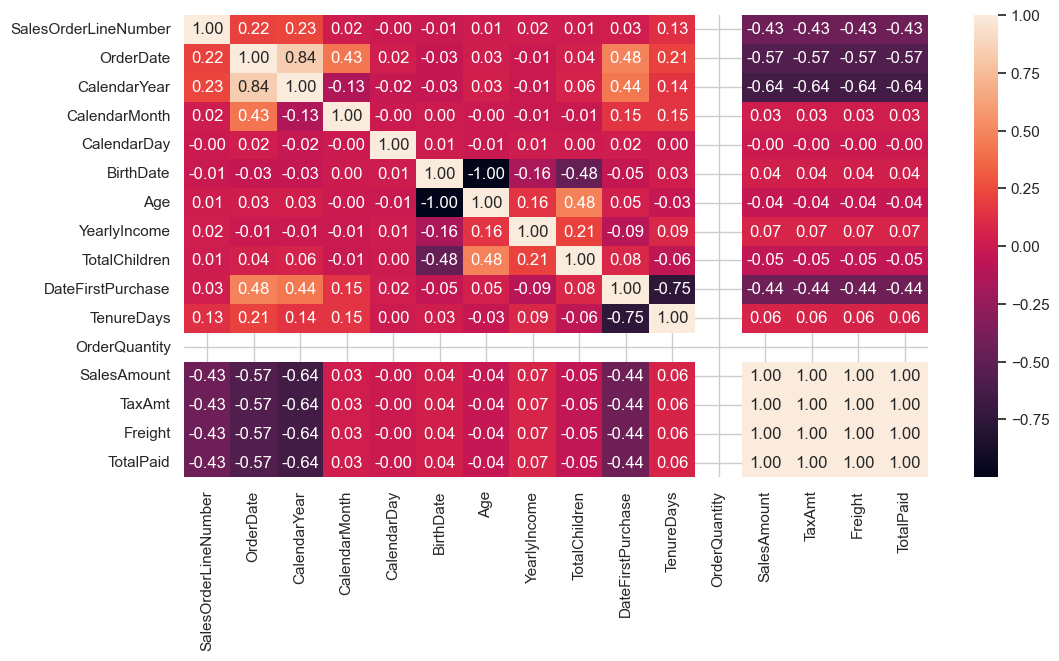

In [180]:
#corr between numeric columns
num_df=df.select_dtypes(exclude='O') 
corr=num_df.corr(method='pearson')

plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, fmt=".2f", )

plt.show()


SalesOrderLineNumber


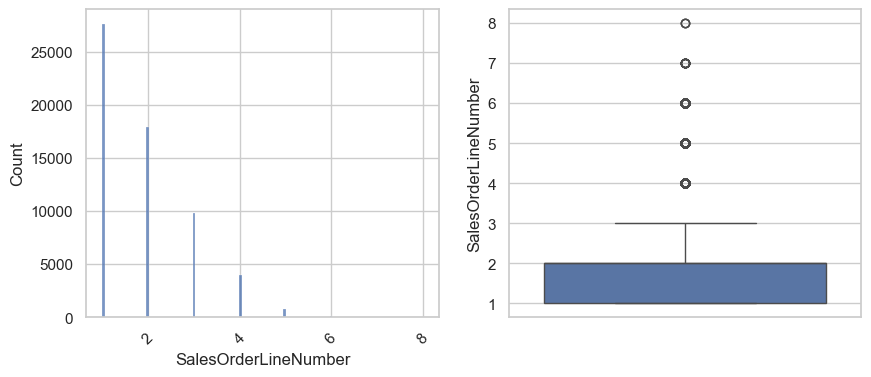

OrderDate


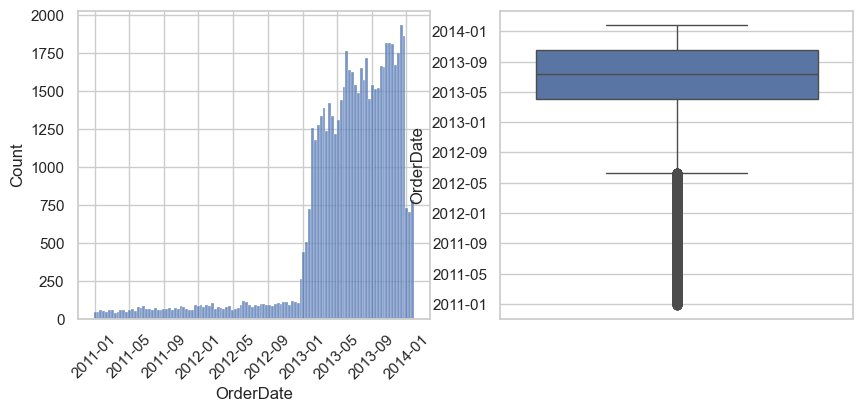

CalendarYear


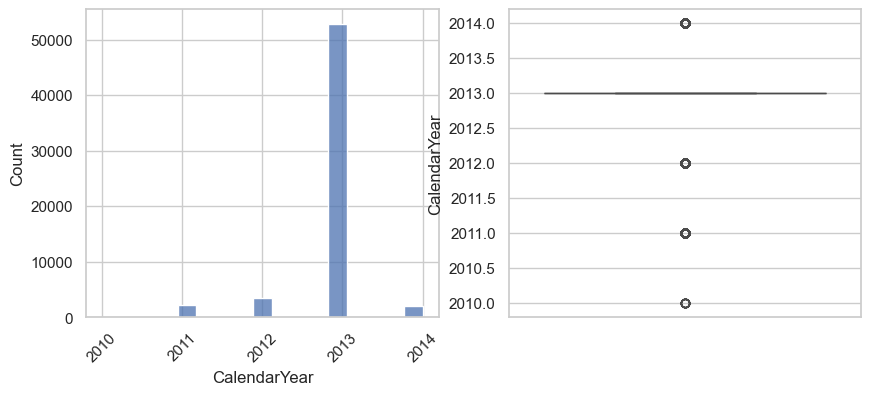

CalendarMonth


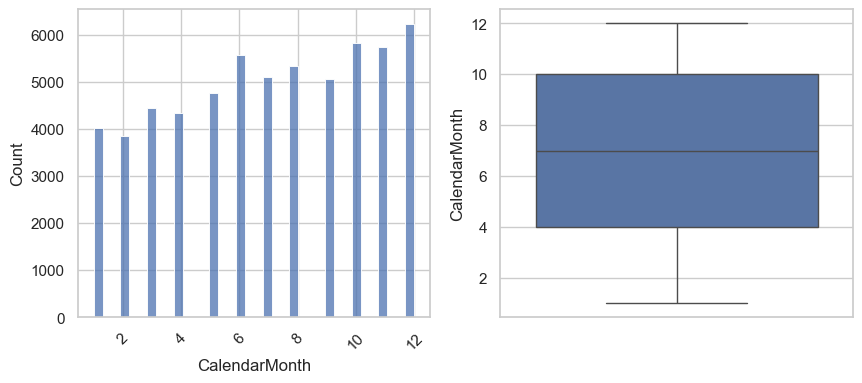

CalendarDay


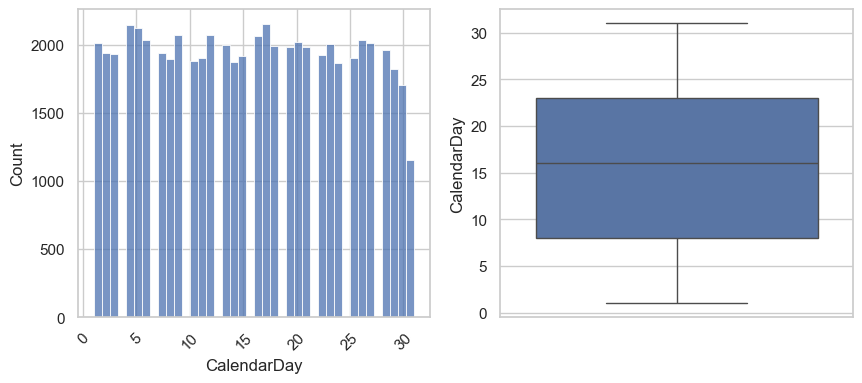

BirthDate


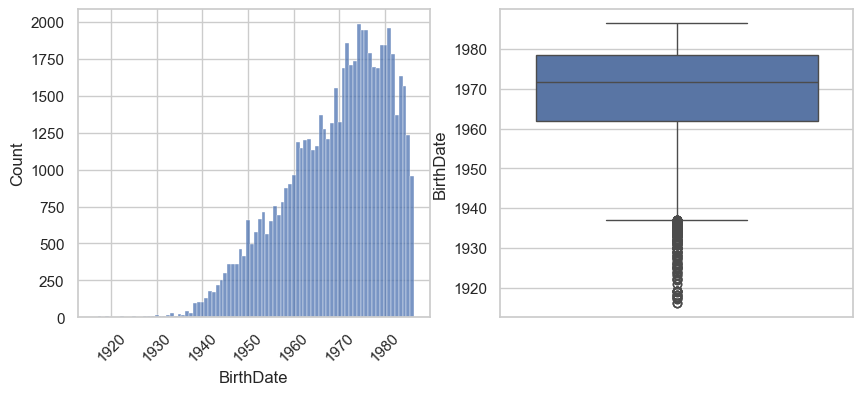

Age


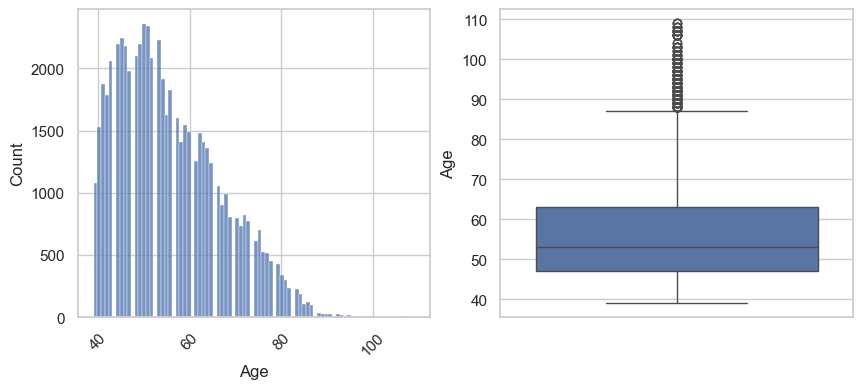

YearlyIncome


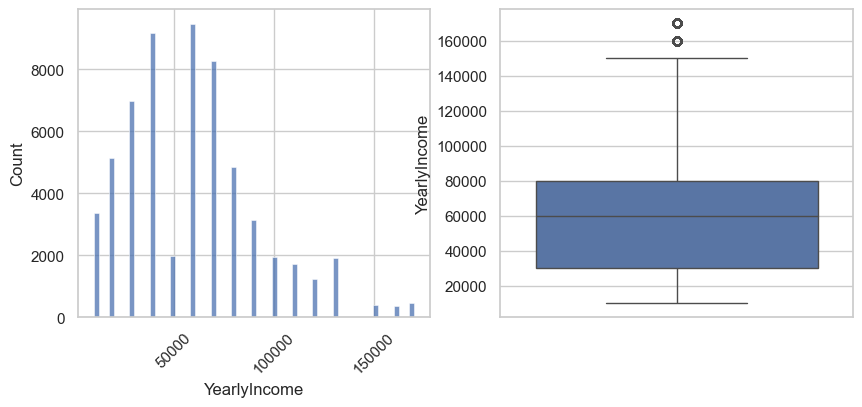

TotalChildren


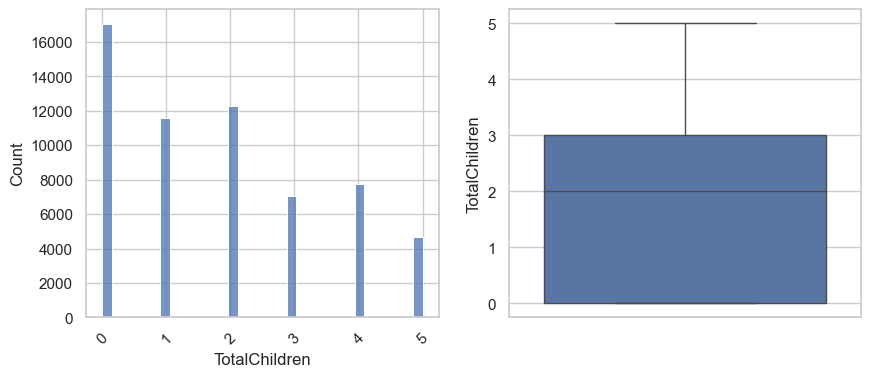

DateFirstPurchase


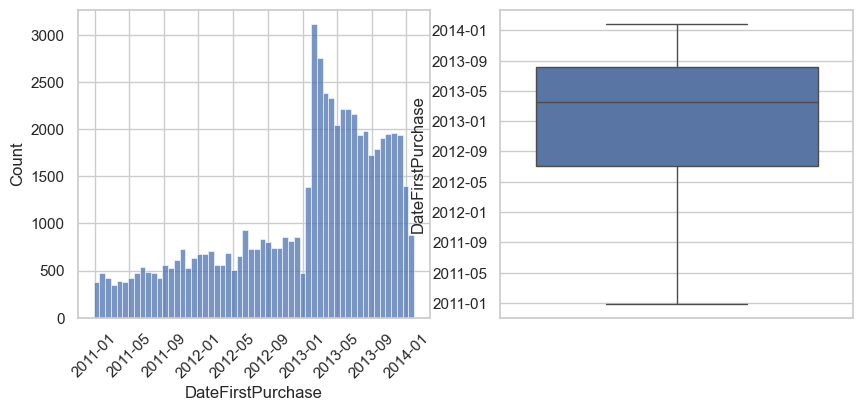

TenureDays


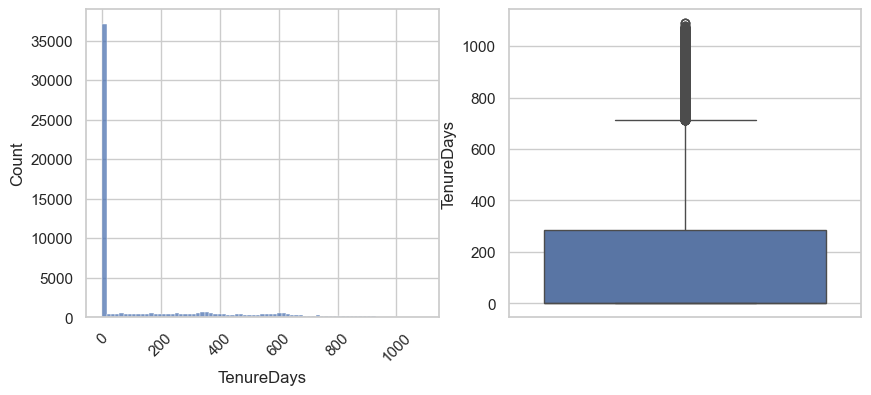

OrderQuantity


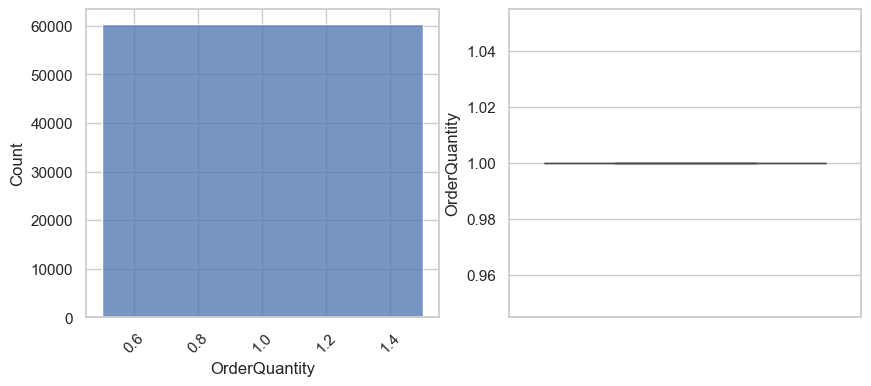

SalesAmount


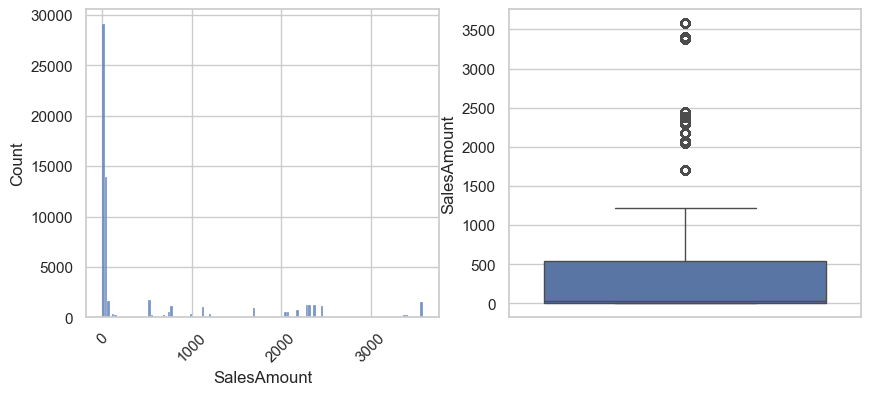

TaxAmt


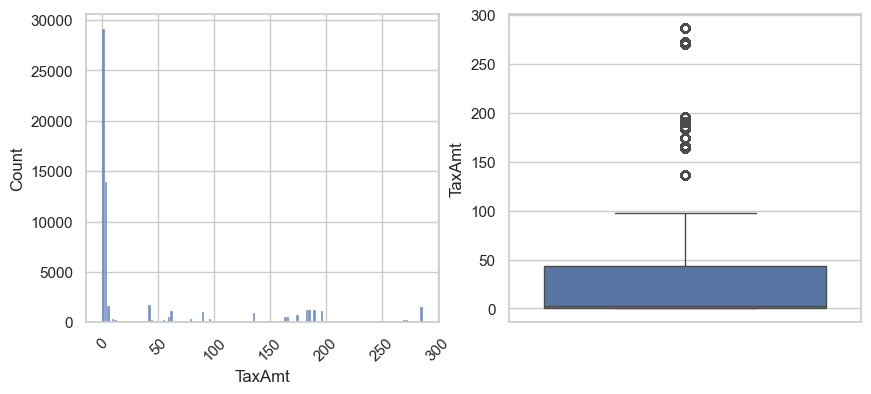

Freight


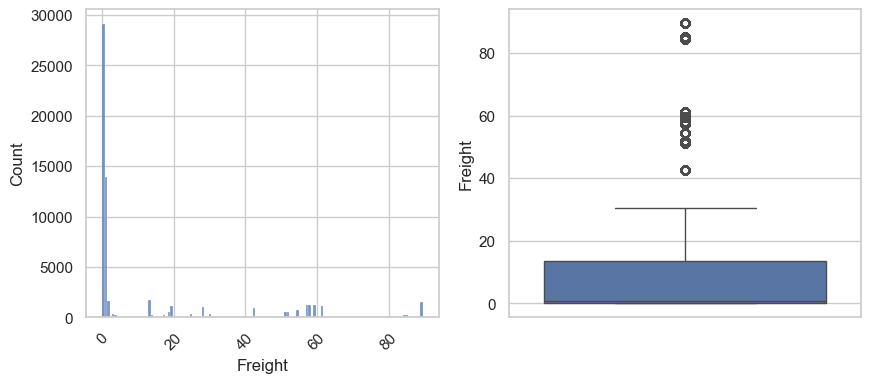

TotalPaid


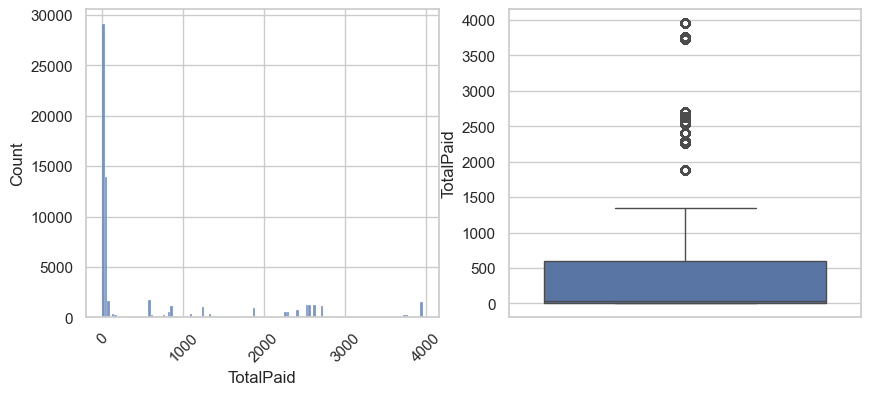

In [181]:
#uni variate
#numeric columns
for col in num_df:
    print(col)
    fig , axes = plt.subplots(1,2, figsize=(10,4))
    sns.histplot(df[col],ax=axes[0])
    axes[0].tick_params(axis='x', rotation=45)
    sns.boxplot(df[col],ax=axes[1]) 
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.show()


SalesOrderNumber


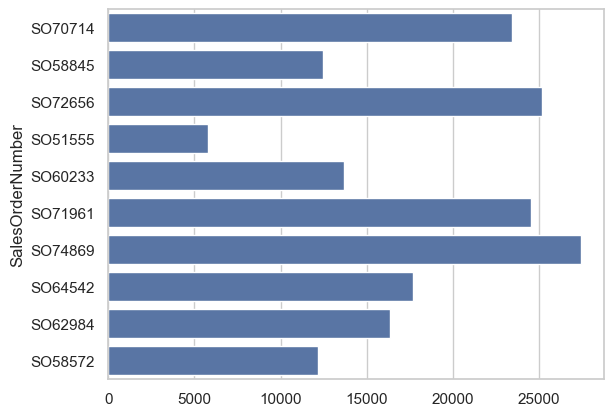

EnglishMonthName


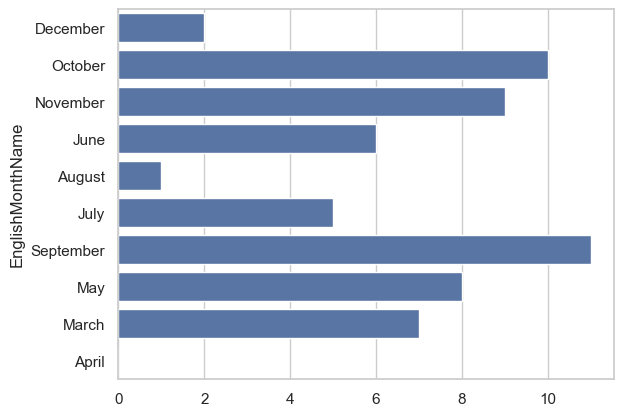

FullName


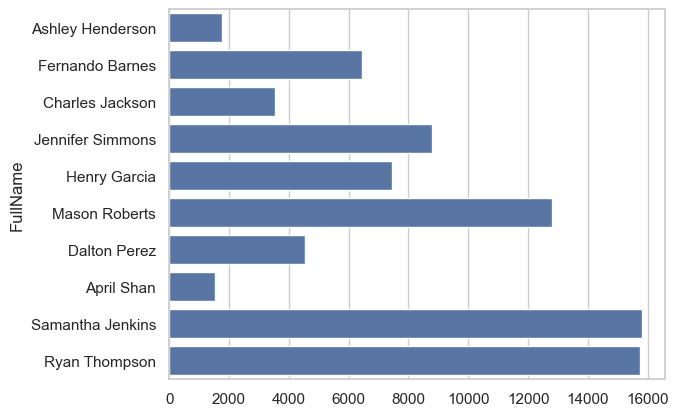

Gender


MaritalStatus


City


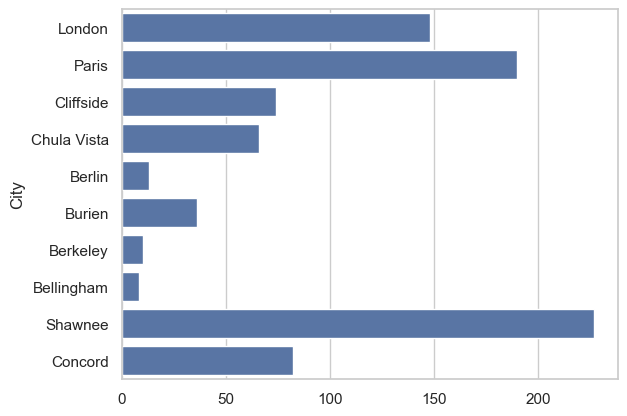

EnglishCountryRegionName


SalesTerritoryGroup


EnglishProductName


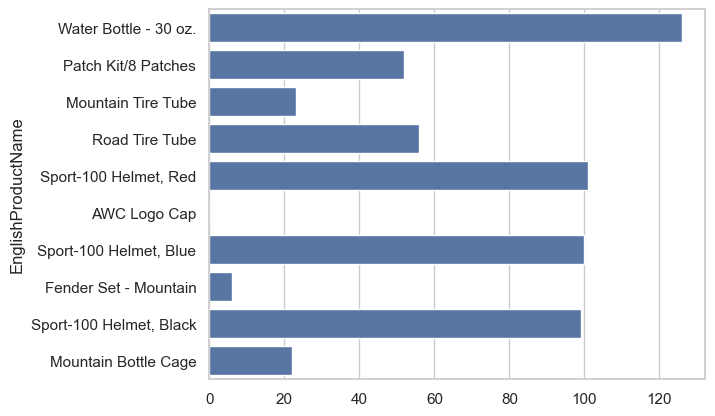

Color


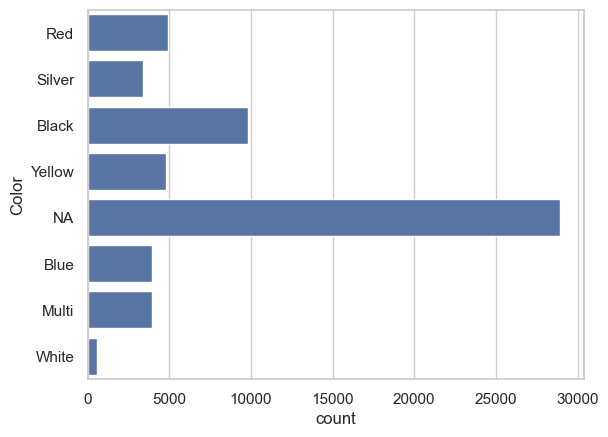

Class


ProductLine


In [182]:
# cat columns
cat_col =df.select_dtypes(include='O').columns
for col in cat_col:
    print(col)
    if df[col].nunique() < 7:
        dff=df.groupby(col)['TotalPaid'].count().reset_index()
        fig=px.pie(dff,names=dff[col],values='TotalPaid')
        fig.show()
    elif df[col].nunique() < 10:
        sns.countplot(df[col])
        plt.show()
    else: 
        dff=df.groupby(col)['TotalPaid'].count().reset_index().sort_values(by='TotalPaid' , ascending=False).head(10)
        sns.barplot(dff[col])
        plt.show()

        

   
    
        
    

In [183]:
df[df['FullName']=='Brad She']

,SalesOrderNumber,SalesOrderLineNumber,OrderDate,CalendarYear,CalendarMonth,CalendarDay,EnglishMonthName,FullName,Gender,MaritalStatus,...,SalesTerritoryGroup,EnglishProductName,Color,Class,ProductLine,OrderQuantity,SalesAmount,TaxAmt,Freight,TotalPaid
767,SO44729,1,2011-05-29,2011,5,29,May,Brad She,M,M,...,Europe,"Road-150 Red, 62",Red,H,R,1,3578.27,286.2616,89.4568,3953.9884
5630,SO51248,1,2013-01-01,2013,1,1,January,Brad She,M,M,...,Europe,"Road-250 Black, 52",Black,H,R,1,2443.35,195.4680,61.0838,2699.9018
18205,SO56795,1,2013-04-25,2013,4,25,April,Brad She,M,M,...,Europe,"Touring-1000 Yellow, 50",Yellow,H,T,1,2384.07,190.7256,59.6018,2634.3974
18206,SO56795,2,2013-04-25,2013,4,25,April,Brad She,M,M,...,Europe,Road Bottle Cage,NA,Unknown,R,1,8.99,0.7192,0.2248,9.9340
18207,SO56795,3,2013-04-25,2013,4,25,April,Brad She,M,M,...,Europe,Water Bottle - 30 oz.,NA,Unknown,S,1,4.99,0.3992,0.1248,5.5140
18208,SO56795,4,2013-04-25,2013,4,25,April,Brad She,M,M,...,Europe,"Half-Finger Gloves, S",Black,Unknown,S,1,24.49,1.9592,0.6123,27.0615
18808,SO57242,1,2013-05-01,2013,5,1,May,Brad She,M,M,...,Europe,"Mountain-200 Black, 46",Black,H,M,1,2294.99,183.5992,57.3748,2535.9640
18809,SO57242,2,2013-05-01,2013,5,1,May,Brad She,M,M,...,Europe,Mountain Bottle Cage,NA,Unknown,M,1,9.99,0.7992,0.2498,11.0390
18810,SO57242,3,2013-05-01,2013,5,1,May,Brad She,M,M,...,Europe,Water Bottle - 30 oz.,NA,Unknown,S,1,4.99,0.3992,0.1248,5.5140
18811,SO57242,4,2013-05-01,2013,5,1,May,Brad She,M,M,...,Europe,"Sport-100 Helmet, Blue",Blue,Unknown,S,1,34.99,2.7992,0.8748,38.6640


In [184]:
# bi variate
#Q1 the 40 customers who spent the most money in total paid in all orders
dff = df.groupby(['FullName','EnglishCountryRegionName'])['TotalPaid'].sum().reset_index().sort_values(by='TotalPaid', ascending=False).head(40)

px.bar(x=dff['FullName'], y=dff['TotalPaid'], title='Highest Spending Customers',color=dff['EnglishCountryRegionName'])



In [185]:
df.columns

Index(['SalesOrderNumber', 'SalesOrderLineNumber', 'OrderDate', 'CalendarYear',
       'CalendarMonth', 'CalendarDay', 'EnglishMonthName', 'FullName',
       'Gender', 'MaritalStatus', 'BirthDate', 'Age', 'YearlyIncome',
       'TotalChildren', 'DateFirstPurchase', 'TenureDays', 'City',
       'EnglishCountryRegionName', 'SalesTerritoryGroup', 'EnglishProductName',
       'Color', 'Class', 'ProductLine', 'OrderQuantity', 'SalesAmount',
       'TaxAmt', 'Freight', 'TotalPaid'],
      dtype='object')

In [186]:
# Q2 what is the average spend by gender
dff = df.groupby(['Gender'])['TotalPaid'].mean().reset_index()
px.pie(dff, 'Gender', 'TotalPaid', title='average spend by gender')



In [187]:
# Q3 what is the average spend by  marital status
dff = df.groupby(['MaritalStatus'])['TotalPaid'].mean().reset_index()
px.bar(dff, 'MaritalStatus', 'TotalPaid', title='average spend by Marital Status', color='MaritalStatus')


In [188]:
#Q4 which age group spend money the most
df['AgeGroup'] = pd.qcut(df['Age'], q=10)
df['AgeGroup'] = df['AgeGroup'].astype(str)
dff = df.groupby('AgeGroup')['TotalPaid'].sum().reset_index()
px.bar(dff, 'AgeGroup', 'TotalPaid', title='Total Spend by Age Group')

C:\Users\MichaelM\AppData\Local\Temp\ipykernel_35756\4209385497.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\MichaelM\AppData\Local\Temp\ipykernel_35756\4209385497.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [189]:
#Q5 customers with high tenure and total spend
dff=df.groupby('FullName').agg({'SalesAmount':'sum', 'TenureDays':'max' }).reset_index().sort_values(by=['SalesAmount','TenureDays'], ascending=False).head(40)
px.scatter(dff,'SalesAmount','TenureDays',hover_name='FullName',title='customers with high tenure and total spend')

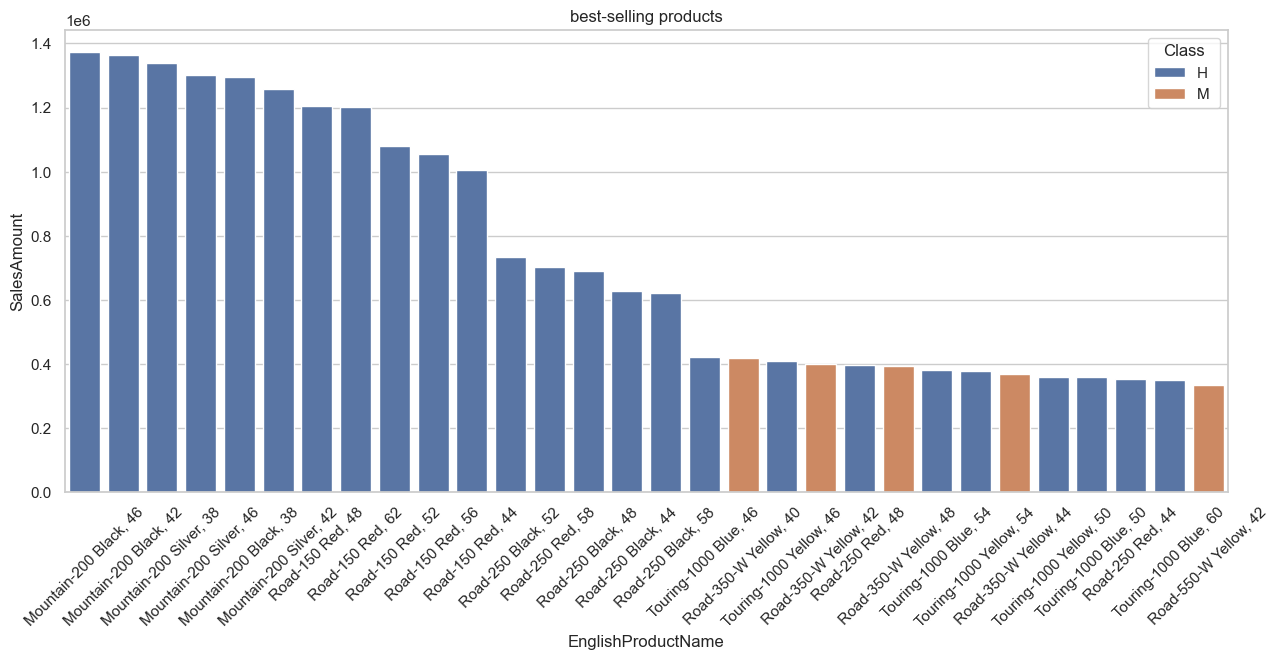

In [190]:
#Q6 which products have highest total sales amount and class
dff=df.groupby(['EnglishProductName','Class'])['SalesAmount'].sum().reset_index().sort_values(by='SalesAmount', ascending=False).head(30)
plt.figure(figsize=(15,6))
sns.barplot(data=dff,x='EnglishProductName',y='SalesAmount',hue='Class')
plt.title('best-selling products')
plt.tick_params('x',rotation=45)
plt.show()

In [191]:
#Q7 how does the class affect on the total sales
dff = df.groupby('Class')['TotalPaid'].sum().reset_index()
fig = px.pie(dff, names='Class', values='TotalPaid', title='Total Sales by Product Class')
fig.show()


In [192]:
# Q8 want to know how which productline is the highest paid with the class
dff = df.groupby(['ProductLine','Class'])['TotalPaid'].sum().reset_index()
fig = px.bar(dff,x='ProductLine',y='TotalPaid',color='Class',barmode='stack',title='total paid dist by Product Line and Class')
fig.show()


In [193]:
#want to know how many Unknowns in class based on productline   
df[df['Class'] == 'Unknown']['ProductLine'].value_counts()

ProductLine
S     23358
M      8509
R      4656
T      2423
Name: count, dtype: int64

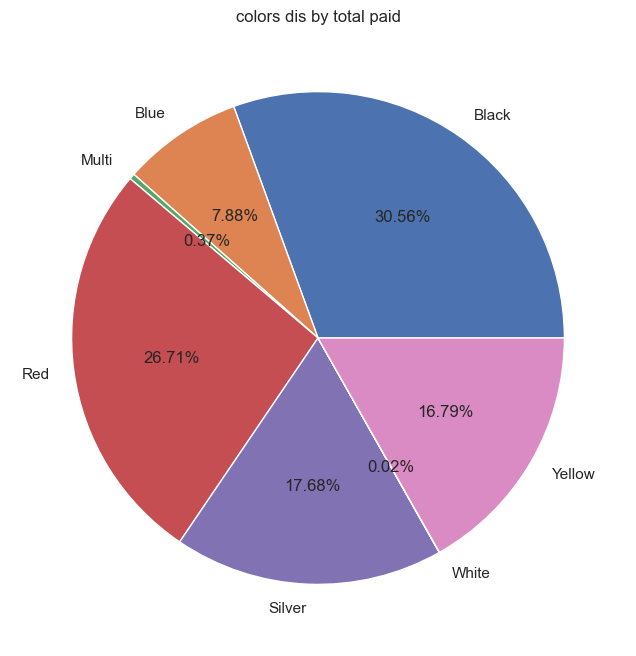

In [194]:
#Q9 which colors most paid 
# we know color have 'NA' values from value_counts 
dff = df[df['Color'] != 'NA'].groupby(['Color'])['TotalPaid'].sum().reset_index()
dff
plt.figure(figsize=(8,8))
plt.pie(dff['TotalPaid'],labels=dff['Color'],autopct='%1.2f%%' )
plt.title('colors dis by total paid')
plt.show()


In [195]:
df

,SalesOrderNumber,SalesOrderLineNumber,OrderDate,CalendarYear,CalendarMonth,CalendarDay,EnglishMonthName,FullName,Gender,MaritalStatus,...,EnglishProductName,Color,Class,ProductLine,OrderQuantity,SalesAmount,TaxAmt,Freight,TotalPaid,AgeGroup
0,SO43697,1,2010-12-29,2010,12,29,December,Cole Watson,M,S,...,"Road-150 Red, 62",Red,H,R,1,3578.2700,286.2616,89.4568,3953.9884,"(72.0, 109.0]"
1,SO43698,1,2010-12-29,2010,12,29,December,Rachael Martinez,F,S,...,"Mountain-100 Silver, 44",Silver,H,M,1,3399.9900,271.9992,84.9998,3756.9890,"(53.0, 57.0]"
2,SO43699,1,2010-12-29,2010,12,29,December,Sydney Wright,F,S,...,"Mountain-100 Silver, 44",Silver,H,M,1,3399.9900,271.9992,84.9998,3756.9890,"(72.0, 109.0]"
3,SO43700,1,2010-12-29,2010,12,29,December,Ruben Prasad,M,M,...,"Road-650 Black, 62",Black,L,R,1,699.0982,55.9279,17.4775,772.5036,"(72.0, 109.0]"
4,SO43701,1,2010-12-29,2010,12,29,December,Christy Zhu,F,S,...,"Mountain-100 Silver, 44",Silver,H,M,1,3399.9900,271.9992,84.9998,3756.9890,"(48.0, 51.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO75122,1,2014-01-28,2014,1,28,January,Caleb Lal,M,S,...,Fender Set - Mountain,NA,Unknown,M,1,21.9800,1.7584,0.5495,24.2879,"(45.0, 48.0]"
60394,SO75122,2,2014-01-28,2014,1,28,January,Caleb Lal,M,S,...,AWC Logo Cap,Multi,Unknown,S,1,8.9900,0.7192,0.2248,9.9340,"(45.0, 48.0]"
60395,SO75123,1,2014-01-28,2014,1,28,January,Devin Phillips,M,S,...,Fender Set - Mountain,NA,Unknown,M,1,21.9800,1.7584,0.5495,24.2879,"(38.999, 42.0]"
60396,SO75123,2,2014-01-28,2014,1,28,January,Devin Phillips,M,S,...,All-Purpose Bike Stand,NA,Unknown,M,1,159.0000,12.7200,3.9750,175.6950,"(38.999, 42.0]"


In [196]:
#tax is fixed acroos all countries
df['TaxRate%'] = (df['TaxAmt'] / df['TotalPaid']) * 100
dff = df.groupby('EnglishCountryRegionName')['TaxRate%'] .agg(['mean','min','max','count']) .reset_index() .sort_values(by='mean', ascending=False)
dff

C:\Users\MichaelM\AppData\Local\Temp\ipykernel_35756\1762046347.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,EnglishCountryRegionName,mean,min,max,count
0,Australia,7.239794,7.239676,7.239824,13345
3,Germany,7.239792,7.239676,7.239824,5625
5,United States,7.239791,7.239676,7.239824,21344
4,United Kingdom,7.239791,7.239676,7.239824,6906
2,France,7.239790,7.239676,7.239824,5558
1,Canada,7.239786,7.239676,7.239824,7620


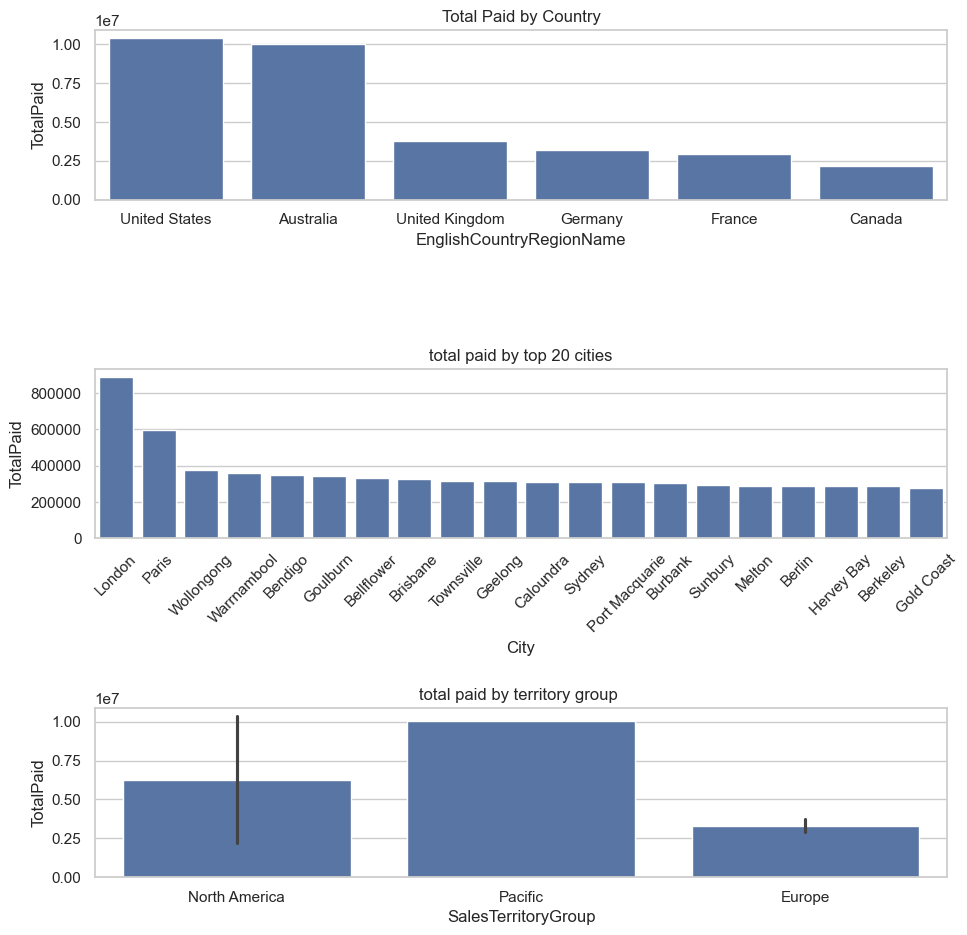

In [197]:
#Q10 countries , top 20 cities have the highest total paid and territory
dff = df.groupby(['EnglishCountryRegionName','SalesTerritoryGroup'])['TotalPaid'].sum().reset_index().sort_values(by='TotalPaid', ascending=False)
dff2= df.groupby('City')['TotalPaid'] .sum().reset_index().sort_values(by='TotalPaid', ascending=False).head(20)

fig , axes = plt.subplots(3,1, figsize=(11,11),gridspec_kw={'hspace': 1})
sns.barplot(data=dff,x='EnglishCountryRegionName',y='TotalPaid',ax=axes[0])
sns.barplot(data=dff2,x='City',y='TotalPaid',ax=axes[1])
sns.barplot(data=dff,x='SalesTerritoryGroup',y='TotalPaid',ax=axes[2])

axes[0].set_title('Total Paid by Country')
axes[1].set_title('total paid by top 20 cities')
axes[1].tick_params('x',rotation=45)
axes[2].set_title('total paid by territory group ')


plt.show()

In [198]:
#Q11 is total paid increases every year
dff=df.groupby('CalendarYear')['TotalPaid'].sum().reset_index().sort_values(by='CalendarYear', ascending=False)
px.line(dff,'CalendarYear','TotalPaid',title='year-over-year growth in total paid').update_xaxes(dtick=1)

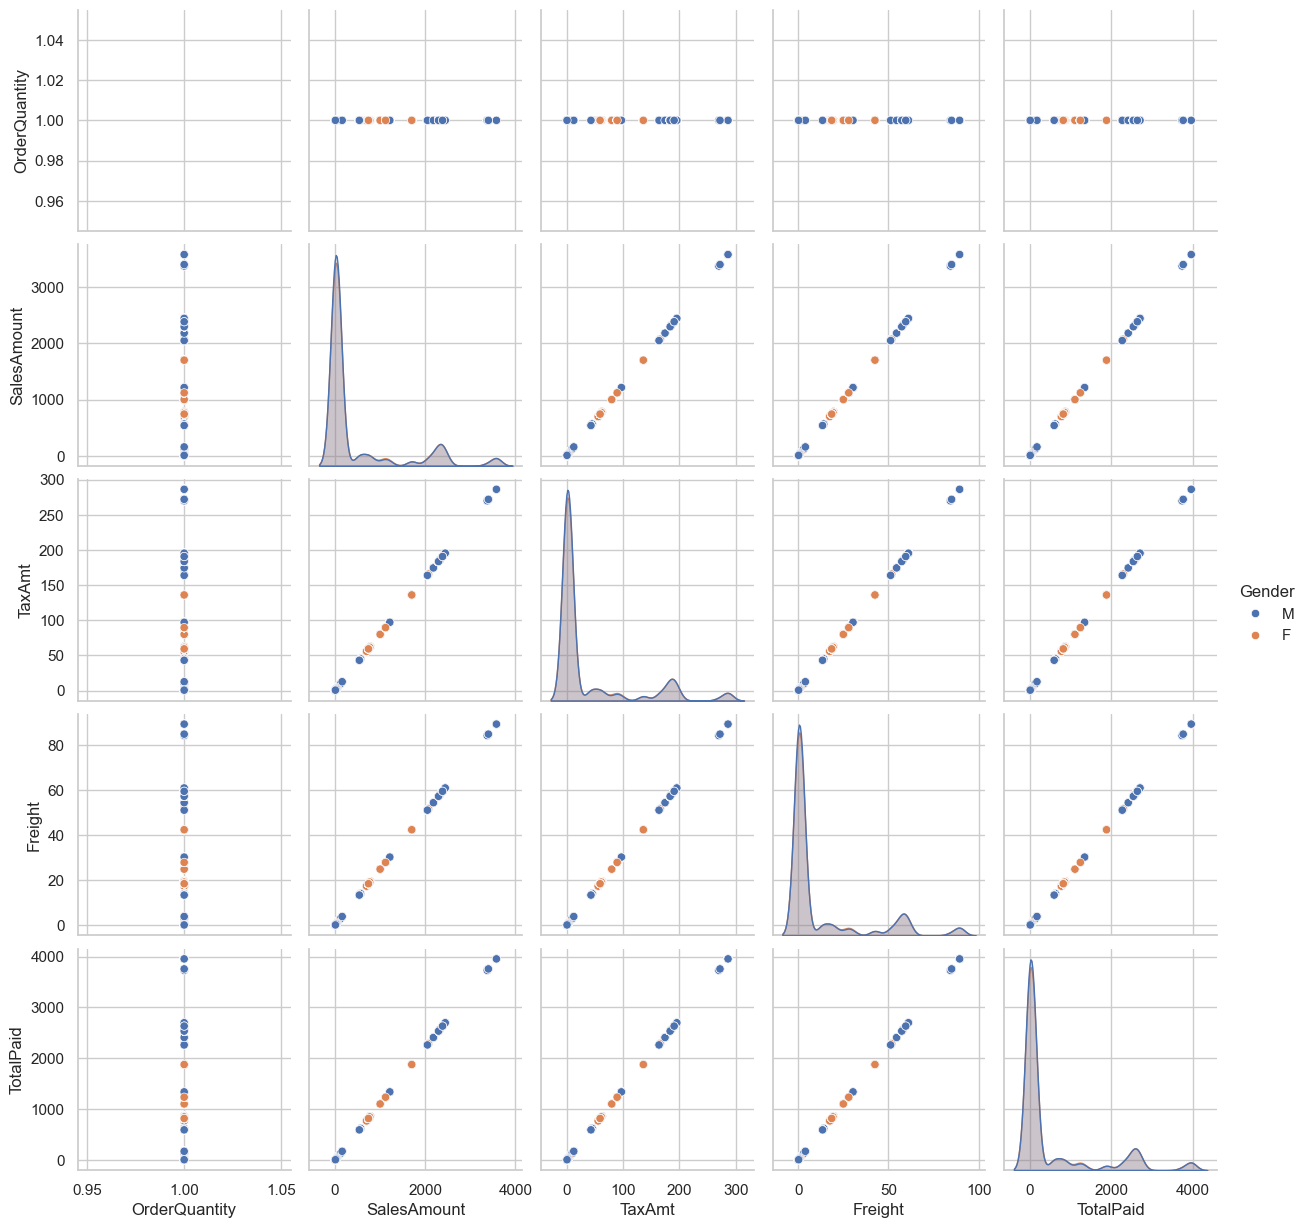

In [199]:
#multi variate

cols = ['OrderQuantity', 'SalesAmount', 'TaxAmt', 'Freight', 'TotalPaid', 'Gender']
sns.pairplot(df[cols], hue='Gender', diag_kind='kde')

plt.show()

#### preprocessing


In [240]:
#i need to make agg because i will make the target totalpaid for each order and the order have many orders line so i need to group them
df_orders = df.groupby('SalesOrderNumber').agg({
    'FullName':'first',
    'CalendarYear': 'min', 
    'CalendarMonth': 'min', 
    'CalendarDay': 'min',         
    'Gender': 'first',             
    'MaritalStatus': 'first',
    'Age': 'first',
    'YearlyIncome': 'first',
    'TenureDays': 'first',
    'City': 'first',
    'EnglishCountryRegionName': 'first',
    'SalesTerritoryGroup': 'first',
    'TotalChildren':'min',
    'OrderQuantity': 'sum',       
    'TotalPaid': 'sum', 
               
}).reset_index()
df_orders


,SalesOrderNumber,FullName,CalendarYear,CalendarMonth,CalendarDay,Gender,MaritalStatus,Age,YearlyIncome,TenureDays,City,EnglishCountryRegionName,SalesTerritoryGroup,TotalChildren,OrderQuantity,TotalPaid
0,SO43697,Cole Watson,2010,12,29,M,S,73,70000.0,0,Metchosin,Canada,North America,5,1,3953.9884
1,SO43698,Rachael Martinez,2010,12,29,F,S,55,20000.0,0,Pantin,France,Europe,3,1,3756.9890
2,SO43699,Sydney Wright,2010,12,29,F,S,73,40000.0,0,Lebanon,United States,North America,5,1,3756.9890
3,SO43700,Ruben Prasad,2010,12,29,M,M,81,80000.0,0,Beverly Hills,United States,North America,4,1,772.5036
4,SO43701,Christy Zhu,2010,12,29,F,S,51,70000.0,0,North Ryde,Australia,Pacific,0,1,3756.9890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27654,SO75119,Alexandria Howard,2014,1,28,F,S,63,60000.0,294,Everett,United States,North America,2,3,46.7195
27655,SO75120,Olivia Stewart,2014,1,28,F,M,43,30000.0,79,Newton,Canada,North America,0,3,93.8809
27656,SO75121,Noah Hall,2014,1,28,M,S,39,30000.0,267,Oak Bay,Canada,North America,0,3,82.8530
27657,SO75122,Caleb Lal,2014,1,28,M,S,48,60000.0,254,Sooke,Canada,North America,1,2,34.2219


In [241]:
df_orders.to_csv('df_orders.csv',index=False)

In [242]:
#handle duplicates
df_orders.duplicated().sum()

np.int64(0)

In [243]:
#b) train_test_split
X =df_orders.drop(['TotalPaid','SalesOrderNumber','FullName'],axis=1) 
y=df_orders['TotalPaid']
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((22127, 13), (5532, 13), (22127,), (5532,))

In [244]:
# handle nans
X_train.isna().sum()

CalendarYear                0
CalendarMonth               0
CalendarDay                 0
Gender                      0
MaritalStatus               0
Age                         0
YearlyIncome                0
TenureDays                  0
City                        0
EnglishCountryRegionName    0
SalesTerritoryGroup         0
TotalChildren               0
OrderQuantity               0
dtype: int64

In [245]:
#detect and handle outliers

num_cols = ['OrderQuantity', 'Age', 'YearlyIncome', 'TenureDays','TotalChildren']

for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"{col}:{lower_bound,upper_bound}")
    outliers = X_train[col][(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

OrderQuantity:(np.float64(-2.0), np.float64(6.0))
OrderQuantity: 12 outliers
Age:(np.float64(20.5), np.float64(88.5))
Age: 81 outliers
YearlyIncome:(np.float64(-45000.0), np.float64(155000.0))
YearlyIncome: 278 outliers
TenureDays:(np.float64(-258.0), np.float64(430.0))
TenureDays: 3007 outliers
TotalChildren:(np.float64(-4.5), np.float64(7.5))
TotalChildren: 0 outliers


In [246]:
X_train['OrderQuantity']=X_train['OrderQuantity'].clip(lower=0 ,upper=6.0)

In [247]:
X_test['OrderQuantity']=X_test['OrderQuantity'].clip(lower=0 ,upper=6.0)

In [248]:
X_train['Age']=X_train['Age'].clip(lower=20.5 ,upper=88.5)

In [249]:
X_test['Age']=X_test['Age'].clip(lower=20.5 ,upper=88.5)

In [250]:
X_train['YearlyIncome'] = X_train['YearlyIncome'].clip(lower=0, upper=155000)
X_test['YearlyIncome']  = X_test['YearlyIncome'].clip(lower=0, upper=155000)
X_train['TenureDays'] = X_train['TenureDays'].clip(lower=0, upper=430)
X_test['TenureDays']  = X_test['TenureDays'].clip(lower=0, upper=430)


In [251]:
X_train[['YearlyIncome','TenureDays']] = np.log1p(X_train[['YearlyIncome','TenureDays']])
X_test[['YearlyIncome','TenureDays']]  = np.log1p(X_test[['YearlyIncome','TenureDays']])

In [252]:
for col in num_cols:
    print(col)
    fig=px.box(X_train,col)
    fig.show()
    fig=px.histogram(X_train,col)
    fig.show()

OrderQuantity


Age


YearlyIncome


TenureDays


TotalChildren


In [253]:
#encoded
cate_col=X_train.select_dtypes(include='O').columns
for col in cate_col:
    print(col,X_train[col].nunique())


Gender 2
MaritalStatus 2
City 265
EnglishCountryRegionName 6
SalesTerritoryGroup 3


In [254]:
hot_encoded_col=['Gender','MaritalStatus','EnglishCountryRegionName','SalesTerritoryGroup']
hot_encoder=OneHotEncoder(sparse_output=False) 
hot_encoded_train=hot_encoder.fit_transform(X_train[hot_encoded_col])
hot_encoded_train
hot_encoded_train_df = pd.DataFrame(hot_encoded_train, columns=hot_encoder.get_feature_names_out(hot_encoded_col), index=X_train.index)
hot_encoded_train_df
X_train_encode = pd.concat([X_train.drop(columns=hot_encoded_col), hot_encoded_train_df], axis=1)


hot_encoded_test=hot_encoder.transform(X_test[hot_encoded_col])
hot_encoded_test
hot_encoded_test_df = pd.DataFrame(hot_encoded_test, columns=hot_encoder.get_feature_names_out(hot_encoded_col), index=X_test.index)
hot_encoded_test_df
X_test_encode = pd.concat([X_test.drop(columns=hot_encoded_col), hot_encoded_test_df], axis=1)
X_train_encode






,CalendarYear,CalendarMonth,CalendarDay,Age,YearlyIncome,TenureDays,City,TotalChildren,OrderQuantity,Gender_F,...,MaritalStatus_S,EnglishCountryRegionName_Australia,EnglishCountryRegionName_Canada,EnglishCountryRegionName_France,EnglishCountryRegionName_Germany,EnglishCountryRegionName_United Kingdom,EnglishCountryRegionName_United States,SalesTerritoryGroup_Europe,SalesTerritoryGroup_North America,SalesTerritoryGroup_Pacific
10158,2013,4,17,51.0,11.002117,0.000000,Sunbury,2,2,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24343,2013,11,27,54.0,11.156265,0.000000,Hobart,5,1,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
16631,2013,8,2,65.0,10.596660,5.099866,Port Hammond,2,3,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24866,2013,12,4,60.0,11.289794,6.066108,Goulburn,2,3,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
18436,2013,8,30,65.0,11.156265,6.025866,Milwaukie,3,4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,2013,10,18,45.0,11.918397,6.066108,Perth,0,3,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5390,2012,12,24,73.0,11.951187,0.000000,York,4,1,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
860,2011,6,11,57.0,10.308986,0.000000,Kirkby,1,1,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
15795,2013,7,19,50.0,11.156265,6.066108,Sunbury,0,2,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [255]:
binary_encoder=BinaryEncoder()
binary_encoder_train=binary_encoder.fit_transform(X_train['City'])
X_train_encoded=pd.concat([X_train_encode.drop(columns='City'),binary_encoder_train], axis=1)


binary_encoder_test=binary_encoder.transform(X_test['City'])
X_test_encoded=pd.concat([X_test_encode.drop(columns='City'),binary_encoder_test], axis=1)
X_train_encoded

,CalendarYear,CalendarMonth,CalendarDay,Age,YearlyIncome,TenureDays,TotalChildren,OrderQuantity,Gender_F,Gender_M,...,SalesTerritoryGroup_Pacific,City_0,City_1,City_2,City_3,City_4,City_5,City_6,City_7,City_8
10158,2013,4,17,51.0,11.002117,0.000000,2,2,1.0,0.0,...,1.0,0,0,0,0,0,0,0,0,1
24343,2013,11,27,54.0,11.156265,0.000000,5,1,1.0,0.0,...,1.0,0,0,0,0,0,0,0,1,0
16631,2013,8,2,65.0,10.596660,5.099866,2,3,0.0,1.0,...,0.0,0,0,0,0,0,0,0,1,1
24866,2013,12,4,60.0,11.289794,6.066108,2,3,1.0,0.0,...,1.0,0,0,0,0,0,0,1,0,0
18436,2013,8,30,65.0,11.156265,6.025866,3,4,0.0,1.0,...,0.0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,2013,10,18,45.0,11.918397,6.066108,0,3,0.0,1.0,...,1.0,0,1,0,1,0,1,0,0,1
5390,2012,12,24,73.0,11.951187,0.000000,4,1,0.0,1.0,...,0.0,0,0,1,0,1,0,1,0,0
860,2011,6,11,57.0,10.308986,0.000000,1,1,1.0,0.0,...,0.0,0,1,1,0,1,0,1,0,0
15795,2013,7,19,50.0,11.156265,6.066108,0,2,1.0,0.0,...,1.0,0,0,0,0,0,0,0,0,1


In [256]:
X_train_encoded['month_sin'] = np.sin(2 * np.pi * X_train_encoded['CalendarMonth'] / 12)
X_train_encoded['month_cos'] = np.cos(2 * np.pi * X_train_encoded['CalendarMonth'] / 12)

X_test_encoded['month_sin'] = np.sin(2 * np.pi * X_test_encoded['CalendarMonth'] / 12)
X_test_encoded['month_cos'] = np.cos(2 * np.pi * X_test_encoded['CalendarMonth'] / 12)



X_train_encoded['day_sin'] = np.sin(2 * np.pi * X_train_encoded['CalendarDay'] / 31)
X_train_encoded['day_cos'] = np.cos(2 * np.pi * X_train_encoded['CalendarDay'] / 31)


X_test_encoded['day_sin'] = np.sin(2 * np.pi * X_test_encoded['CalendarDay'] / 31)
X_test_encoded['day_cos'] = np.cos(2 * np.pi * X_test_encoded['CalendarDay'] / 31)

X_train_encoded = X_train_encoded.drop(columns=['CalendarMonth', 'CalendarDay'])
X_test_encoded = X_test_encoded.drop(columns=['CalendarMonth', 'CalendarDay'])

X_train_encoded



,CalendarYear,Age,YearlyIncome,TenureDays,TotalChildren,OrderQuantity,Gender_F,Gender_M,MaritalStatus_M,MaritalStatus_S,...,City_3,City_4,City_5,City_6,City_7,City_8,month_sin,month_cos,day_sin,day_cos
10158,2013,51.0,11.002117,0.000000,2,2,1.0,0.0,1.0,0.0,...,0,0,0,0,0,1,8.660254e-01,-0.500000,-0.299363,-0.954139
24343,2013,54.0,11.156265,0.000000,5,1,1.0,0.0,1.0,0.0,...,0,0,0,0,1,0,-5.000000e-01,0.866025,-0.724793,0.688967
16631,2013,65.0,10.596660,5.099866,2,3,0.0,1.0,1.0,0.0,...,0,0,0,0,1,1,-8.660254e-01,-0.500000,0.394356,0.918958
24866,2013,60.0,11.289794,6.066108,2,3,1.0,0.0,0.0,1.0,...,0,0,0,1,0,0,-2.449294e-16,1.000000,0.724793,0.688967
18436,2013,65.0,11.156265,6.025866,3,4,0.0,1.0,1.0,0.0,...,0,0,0,1,0,1,-8.660254e-01,-0.500000,-0.201299,0.979530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,2013,45.0,11.918397,6.066108,0,3,0.0,1.0,1.0,0.0,...,1,0,1,0,0,1,-8.660254e-01,0.500000,-0.485302,-0.874347
5390,2012,73.0,11.951187,0.000000,4,1,0.0,1.0,1.0,0.0,...,0,1,0,1,0,0,-2.449294e-16,1.000000,-0.988468,0.151428
860,2011,57.0,10.308986,0.000000,1,1,1.0,0.0,0.0,1.0,...,0,1,0,1,0,0,1.224647e-16,-1.000000,0.790776,-0.612106
15795,2013,50.0,11.156265,6.066108,0,2,1.0,0.0,0.0,1.0,...,0,0,0,0,0,1,-5.000000e-01,-0.866025,-0.651372,-0.758758


In [257]:
num_columns = ['OrderQuantity', 'Age', 'YearlyIncome','TotalChildren','TenureDays', 'CalendarYear', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

std_scaler = StandardScaler()
X_train_encoded[num_columns] = std_scaler.fit_transform(X_train_encoded[num_columns])
X_test_encoded[num_columns] = std_scaler.transform(X_test_encoded[num_columns])


In [258]:
X_train_encoded

,CalendarYear,Age,YearlyIncome,TenureDays,TotalChildren,OrderQuantity,Gender_F,Gender_M,MaritalStatus_M,MaritalStatus_S,...,City_3,City_4,City_5,City_6,City_7,City_8,month_sin,month_cos,day_sin,day_cos
10158,0.387971,-0.399813,0.292600,-0.692020,0.109800,-0.162381,1.0,0.0,1.0,0.0,...,0,0,0,0,0,1,1.354397,-0.707236,-0.419105,-1.329975
24343,0.387971,-0.131278,0.532257,-0.692020,1.966304,-1.043019,1.0,0.0,1.0,0.0,...,0,0,0,0,1,0,-0.622894,1.191151,-1.016420,1.011886
16631,0.387971,0.853350,-0.337773,1.250277,0.109800,0.718257,0.0,1.0,1.0,0.0,...,0,0,0,0,1,1,-1.152708,-0.707236,0.554895,1.339684
24866,0.387971,0.405792,0.739859,1.618273,0.109800,0.718257,1.0,0.0,0.0,1.0,...,0,0,0,1,0,0,0.100844,1.377337,1.018837,1.011886
18436,0.387971,0.853350,0.532257,1.602946,0.728635,1.598895,0.0,1.0,1.0,0.0,...,0,0,0,1,0,1,-1.152708,-0.707236,-0.281420,1.426015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,0.387971,-0.936883,1.717162,1.618273,-1.127870,0.718257,0.0,1.0,1.0,0.0,...,1,0,1,0,0,1,-1.152708,0.682479,-0.680168,-1.216249
5390,-1.163002,1.569443,1.768141,-0.692020,1.347470,-1.043019,0.0,1.0,1.0,0.0,...,0,1,0,1,0,0,0.100844,1.377337,-1.386627,0.245751
860,-2.713975,0.137257,-0.785026,-0.692020,-0.509035,-1.043019,1.0,0.0,0.0,1.0,...,0,1,0,1,0,0,0.100844,-1.402094,1.111479,-0.842487
15795,0.387971,-0.489324,0.532257,1.618273,-1.127870,-0.162381,1.0,0.0,0.0,1.0,...,0,0,0,0,0,1,-0.622894,-1.215907,-0.913336,-1.051505


In [259]:
X_train_encoded.to_csv("train_cleaned_encoded.csv", index=False)
X_test_encoded.to_csv("test_cleaned_encoded.csv", index=False)